######---Collections des donnees via APIs---#####

In [1]:
import pandas as pd
import numpy as np
import requests
import datetime
from mon_outillage import getPayloadData
from mon_outillage import getcoredata
from mon_outillage import getLaunchSite
from mon_outillage import getBoosterVersion
from mon_outillage import pretraitement_data

In [2]:
space_url = "https://api.spacexdata.com/v4/launches/past"
response = requests.get(space_url)
data = pd.json_normalize(response.json())

#Filtrage des donnees en gardant que celle de falcon9 et les colonnes utiles
data = data[['rocket', 'payloads','launchpad','cores', 'flight_number','date_utc']]
data = data[data['cores'].map(len)==1]
data = data[data['payloads'].map(len)==1] #le filtrage de len==1 nous permet lancer des missions simples comme une fusee(rocket) , un satellite et un etage
data['date'] = pd.to_datetime(data['date_utc']).dt.date
data = data[data['date']<=datetime.date(2020, 11, 13)]


In [3]:
#Initialisation des listes pour stocker le resultat des fonctions
BoosterVersion = []
PayloadMass = []
Orbit = []
LaunchSite = []
#++Cores = []
Outcome = []
Flights = []
Reused = []
Leg = []
LandingPad = []
Serial = []
Longitude = []
Latitude = []
GridFins = []
Block = []

#Appel ou execution des APIs secondaire(les fonctions creer)
# 2. Appel des fonctions avec les listes en paramètres
# Assure-toi que data est bien ton DataFrame filtré
getcoredata(data, Block, Reused, Serial, Outcome, Flights, GridFins, Reused, Leg, LandingPad)
getLaunchSite(data, Longitude, Latitude, LaunchSite)
getPayloadData(data, PayloadMass, Orbit)
getBoosterVersion(data, BoosterVersion)

##Lancement de l'API

In [4]:
Reused = Reused[:94]
#ReusedCount = ReusedCount[:94]

##Creation du dictionnaire final
launch_dict = {
    'FlightNumber':list(data['flight_number']),
    'Date':list(data['date']),
    'BoosterVersion':BoosterVersion,
    'PayloadMass':PayloadMass,
    'Orbit':Orbit,
   # 'Cores':Cores,
    'Reused':Reused,
    'LandingPad':LandingPad,
    'Leg':Leg,
    'Serial':Serial,
    'Block':Block,
    'GridFins':GridFins,
    'Latitude':Latitude,
    'Longitude':Longitude,
    'Outcome':Outcome,
    'LaunchSite':LaunchSite,
    'Flight':Flights
}

# Mise à jour du dictio pour des donner noms coherentes
launch_dict['BoosterVersion'] = BoosterVersion
# Vérification des longueurs
print(f"1. FlightNumber: {len(data['flight_number'])}")
print(f"2. Date: {len(data['date'])}")
print(f"3. BoosterVersion: {len(BoosterVersion)}")
print(f"4. PayloadMass: {len(PayloadMass)}")
print(f"5. Orbit: {len(Orbit)}")
print(f"6. LaunchSite: {len(LaunchSite)}")
print(f"7. Outcome: {len(Outcome)}")
print(f"8. Flights: {len(Flights)}")
print(f"9. GridFins: {len(GridFins)}")
print(f"10. Reused: {len(Reused)}")
print(f"11. Leg: {len(Leg)}")
print(f"12. LandingPad: {len(LandingPad)}")
print(f"13. Block: {len(Block)}")
#print(f"14. Reused: {len(Reused)}")
print(f"15. Serial: {len(Serial)}")
print(f"16. Longitude: {len(Longitude)}")
print(f"17. Latitude: {len(Latitude)}")


#Transformation en dataframe final
df = pd.DataFrame(launch_dict)

#Filtrage final pour ne garder que falcon 9
data_falcon9 = df[df['BoosterVersion']!='Falcon 1'].copy()

# 2. ON RÉINITIALISE L'INDEX (Étape manquante cruciale)

data_falcon9.reset_index(drop=True, inplace=True)

#Renumeroter les vols suite a la suppression de falcon1

data_falcon9.loc[:,'FlightNumber'] = list(range(1, data_falcon9.shape[0] + 1))

#Verification final

print(data_falcon9.head())






1. FlightNumber: 94
2. Date: 94
3. BoosterVersion: 94
4. PayloadMass: 94
5. Orbit: 94
6. LaunchSite: 94
7. Outcome: 94
8. Flights: 94
9. GridFins: 94
10. Reused: 94
11. Leg: 94
12. LandingPad: 94
13. Block: 94
15. Serial: 94
16. Longitude: 94
17. Latitude: 94
   FlightNumber        Date BoosterVersion  PayloadMass Orbit Reused  \
0             1  2010-06-04       Falcon 9          NaN   LEO      0   
1             2  2012-05-22       Falcon 9        525.0   LEO  False   
2             3  2013-03-01       Falcon 9        677.0   ISS      0   
3             4  2013-09-29       Falcon 9        500.0    PO  False   
4             5  2013-12-03       Falcon 9       3170.0   GTO      0   

  LandingPad    Leg Serial  Block  GridFins   Latitude   Longitude  \
0       None  False  B0003    1.0     False  28.561857  -80.577366   
1       None  False  B0005    1.0     False  28.561857  -80.577366   
2       None  False  B0007    1.0     False  28.561857  -80.577366   
3       None  False  B1003 

In [5]:
data_falcon9.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        5
Orbit              0
Reused             0
LandingPad        90
Leg                0
Serial             0
Block              0
GridFins           0
Latitude           0
Longitude          0
Outcome            0
LaunchSite         0
Flight             0
dtype: int64

In [6]:
data_falcon9 = pretraitement_data(data_falcon9)
data_falcon9.isnull().sum().sum()

colonnes supprimer (>80%) de vides : ['LandingPad']
 -PayloadMass : Mediane utilise (skew : 0.98)


np.int64(0)

In [7]:
data_falcon9['Reused'] = data_falcon9['Reused'].astype(int)

data_falcon9.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,Reused,Leg,Serial,Block,GridFins,Latitude,Longitude,Outcome,LaunchSite,Flight
0,1,2010-06-04,Falcon 9,4535.0,LEO,0,False,B0003,1.0,False,28.561857,-80.577366,None None,CCSFS SLC 40,1
1,2,2012-05-22,Falcon 9,525.0,LEO,0,False,B0005,1.0,False,28.561857,-80.577366,None None,CCSFS SLC 40,1
2,3,2013-03-01,Falcon 9,677.0,ISS,0,False,B0007,1.0,False,28.561857,-80.577366,None None,CCSFS SLC 40,1
3,4,2013-09-29,Falcon 9,500.0,PO,0,False,B1003,1.0,False,34.632093,-120.610829,False Ocean,VAFB SLC 4E,1
4,5,2013-12-03,Falcon 9,3170.0,GTO,0,False,B1004,1.0,False,28.561857,-80.577366,None None,CCSFS SLC 40,1


########---Module 2 – Exploratory Data Analysis (EDA)---################ 

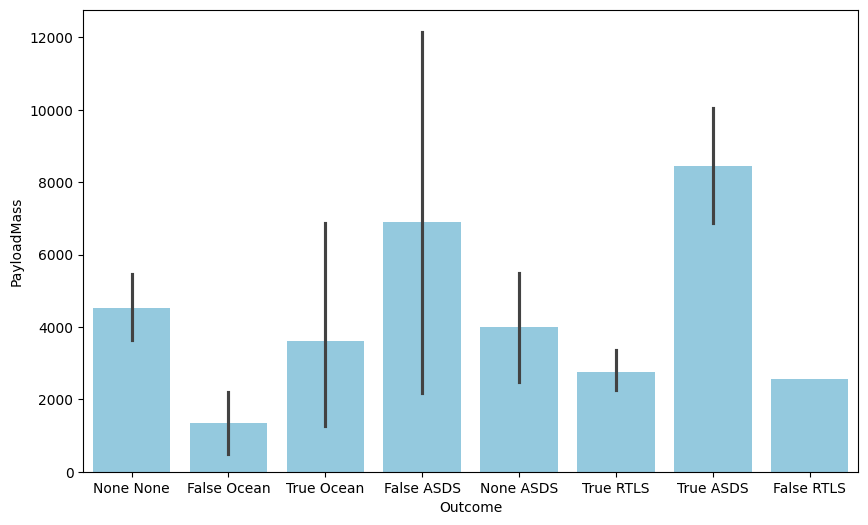

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=data_falcon9, x='Outcome', y = 'PayloadMass',color='skyblue')
plt.show()

##Creation de la colonne target

In [9]:
#creer une liste pour stocker les 0 et 1
class_target = []

for outcome in data_falcon9['Outcome']:
    if 'True' in outcome:
        class_target.append(1)
    else:
        class_target.append(0)


data_falcon9['class'] = class_target

#verifie le taux de succes moyen
print(f"Taux de succes moyen :{data_falcon9['class'].mean():.2%}")


Taux de succes moyen :66.67%


###+++ Analyse Exploratoire avec SQL

In [10]:
!pip install pandasql


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandasql as ps
##La masse moyenne par site
query = """
select LaunchSite,count(LaunchSite) as nombre_lancement,  avg(PayloadMass) as masse_moyenne
from data_falcon9
group by LaunchSite
"""
df_masss_site = ps.sqldf(query, locals())

print(df_masss_site)

     LaunchSite  nombre_lancement  masse_moyenne
0  CCSFS SLC 40                55    5476.755455
1    KSC LC 39A                22    7500.090909
2   VAFB SLC 4E                13    5919.461538


##Visualisation da la moyenne par site

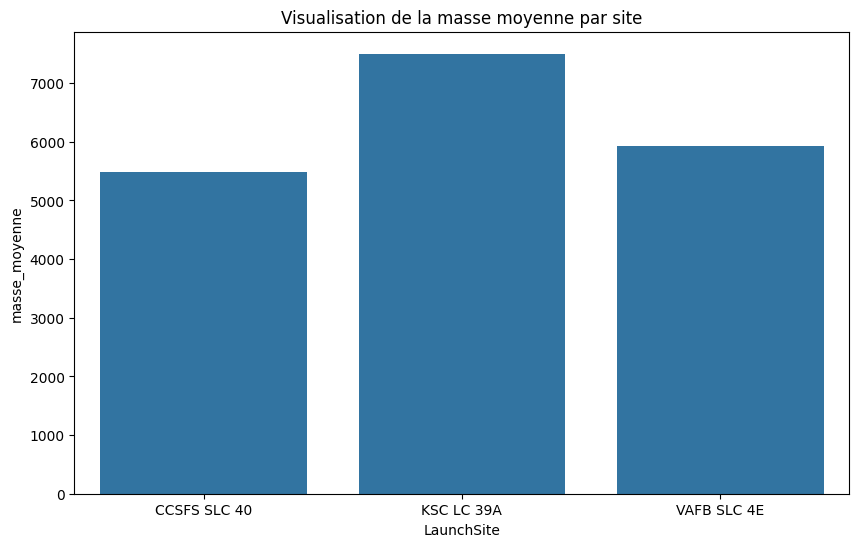

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_masss_site, x= 'LaunchSite', y= 'masse_moyenne')
plt.title("Visualisation de la masse moyenne par site")
plt.show()

In [13]:
#voir la relation entre la cible et le site
query_cible = """
select LaunchSite, class
from data_falcon9
group by LaunchSite
"""
df_cible = ps.sqldf(query_cible, locals())
print(df_cible)

     LaunchSite  class
0  CCSFS SLC 40      0
1    KSC LC 39A      1
2   VAFB SLC 4E      0


##. Liste des sites de lancement uniques

In [14]:
query_site = """
select distinct(LaunchSite)
from data_falcon9
"""
df_site = ps.sqldf(query_site, locals())
print(df_site)


     LaunchSite
0  CCSFS SLC 40
1   VAFB SLC 4E
2    KSC LC 39A


###. Le Top 5 des masses de charges utiles

In [15]:
query_ms = """
select PayloadMass
from data_falcon9
order by PayloadMass desc
limit 5
"""
df_ms = ps.sqldf(query_ms, locals())
print(df_ms)


   PayloadMass
0      15600.0
1      15600.0
2      15600.0
3      15600.0
4      15600.0


###3. Le taux de succès par type d'orbite

In [16]:
query_orbit = """
select Orbit, avg(class) as moyen_succes
from data_falcon9
group by Orbit
"""
df_orbit = ps.sqldf(query_orbit, locals())
print(df_orbit)


    Orbit  moyen_succes
0   ES-L1      1.000000
1     GEO      1.000000
2     GTO      0.518519
3     HEO      1.000000
4     ISS      0.619048
5     LEO      0.714286
6     MEO      0.666667
7      PO      0.666667
8      SO      0.000000
9     SSO      1.000000
10   VLEO      0.857143


###Décompte des atterrissages réussis et échoués

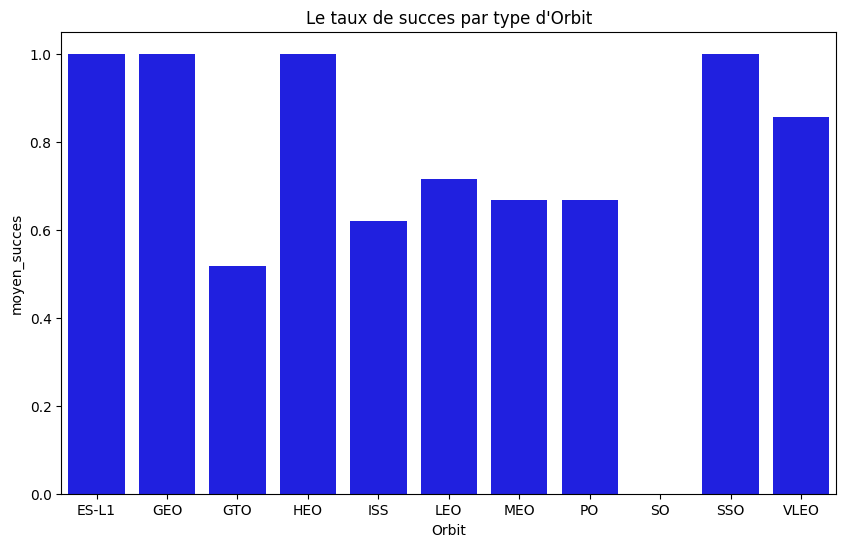

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_orbit, x='Orbit',y='moyen_succes', color='blue')
plt.title("Le taux de succes par type d'Orbit")
plt.show()

In [18]:
query_class = """
select class, count(*) as nombre
from data_falcon9
group by class
"""
df_class = ps.sqldf(query_class, locals())
print(df_class)

   class  nombre
0      0      30
1      1      60


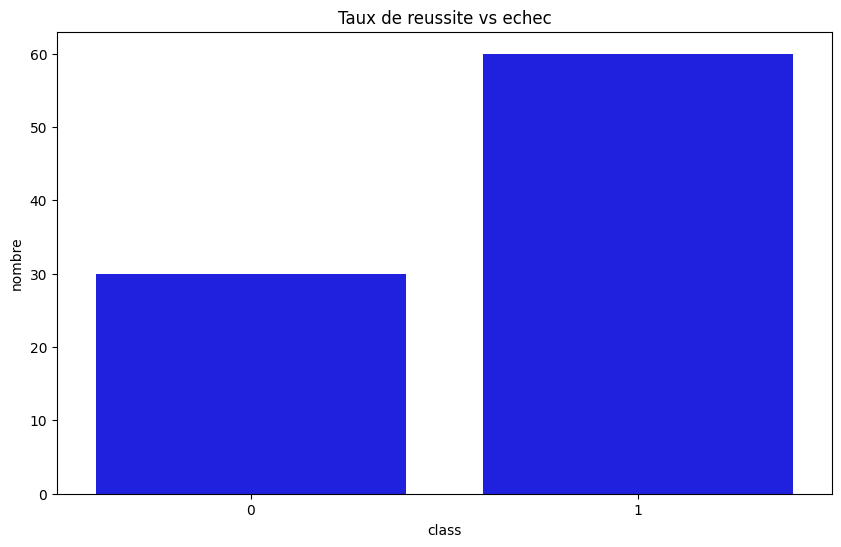

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_class, x='class', y= 'nombre', color='blue')
plt.title("Taux de reussite vs echec")
plt.show()

###--Trouve tous les lancements effectués entre le '2010-06-04' et le '2015-12-31'.

In [20]:
query_st = """
select LaunchSite
from data_falcon9
where Date Between '2010-06-04' and '2015-12-31'
"""

df_st = ps.sqldf(query_st, locals())
print(df_st)

      LaunchSite
0   CCSFS SLC 40
1   CCSFS SLC 40
2   CCSFS SLC 40
3    VAFB SLC 4E
4   CCSFS SLC 40
5   CCSFS SLC 40
6   CCSFS SLC 40
7   CCSFS SLC 40
8   CCSFS SLC 40
9   CCSFS SLC 40
10  CCSFS SLC 40
11  CCSFS SLC 40
12  CCSFS SLC 40
13  CCSFS SLC 40
14  CCSFS SLC 40
15  CCSFS SLC 40
16  CCSFS SLC 40


###Trouve le nombre de succès (Class=1) pour les missions ayant une masse de charge utile supérieure à 5000 kg, mais uniquement pour le site de lancement 'KSC LC 39A

In [21]:
query_suc = """
select class, PayloadMass as masse, LaunchSite as site_lancement
from data_falcon9
where LaunchSite ='KSC LC 39A'
and class = 1
and PayloadMass > 5000
"""
df_sc = ps.sqldf(query_suc, locals())
print(df_sc)


   class    masse site_lancement
0      1   5300.0     KSC LC 39A
1      1   5200.0     KSC LC 39A
2      1  12259.0     KSC LC 39A
3      1  15600.0     KSC LC 39A
4      1   9525.0     KSC LC 39A
5      1  15600.0     KSC LC 39A
6      1  15600.0     KSC LC 39A
7      1  15600.0     KSC LC 39A


In [22]:
!pip install folium


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


###Module 3 – Interactive Visual Analytics and Dashboard  
###Créer une carte interactive avec Folium (localisation des sites de lancement + proximité)  
###Créer un dashboard interactif avec Plotly Dash


In [23]:
import folium

###-On creer la carte avec folium.Map

In [24]:

floride_center =[28.57, -80.64]

#Creation de l'object carte
site_map = folium.Map(location=floride_center, zoom_start = 10)

###-Kennedy Space Center

In [25]:
#Recupere les coordonnes dans le dataframe(data_falcon9)
ksc =[28.573255, -80.646895]

#creer un cercle pour marquer le point exact
circle = folium.Circle(ksc, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('KSC LC-39A'))

#Creer un markeur
marker = folium.Marker(
    ksc,
    icon=folium.DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'KSC LC-39A',
    )
)

#Ajout ces elements a la carte
site_map.add_child(circle)
site_map.add_child(marker)

#Affiche la carte
site_map

In [26]:
from folium.plugins import MarkerCluster

marker_cluster = MarkerCluster().add_to(site_map)

#on parcourt sur chaque element du dataframe
for index, record in data_falcon9.iterrows():
    #vert si class=1 , rouge sinon
    marker_color = 'green' if record['class'] ==1  else 'red'

# Créer un marqueur simple (point de couleur)
    folium.Marker(
        location=[record['Latitude'], record['Longitude']],
        icon=folium.Icon(color='white', icon_color=marker_color),
        popup=f"Site: {record['LaunchSite']} | Success: {record['class']}"
    ).add_to(marker_cluster)

# Afficher la carte mise à jour
site_map    

####--Créer un dashboard interactif avec Plotly Dash

In [27]:
!pip install dash pandas plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

In [29]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd

# 1. Initialisation de l'application
app = dash.Dash(__name__)

# Préparation des options pour le menu déroulant
options = [{'label': 'All Sites', 'value': 'ALL'}]
for site in data_falcon9['LaunchSite'].unique():
    options.append({'label': site, 'value': site})

# 2. Mise en page (Layout)
app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard', 
            style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),
    
    # --- SECTION PIE CHART ---
    dcc.Dropdown(id='site-dropdown',
                options=options,
                value='ALL',
                placeholder="Select a Launch Site here",
                searchable=True),
    html.Br(),
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    # --- SECTION SCATTER CHART ---
    html.P("Payload range (Kg):", style={'font-weight': 'bold'}),
    dcc.RangeSlider(id='payload-slider',
                    min=0, max=10000, step=1000,
                    marks={0: '0', 2500: '2500', 5000: '5000', 7500: '7500', 10000: '10000'},
                    value=[0, 10000]),
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

# 3. Callback pour le Pie Chart (Succès par site)
@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        fig = px.pie(data_falcon9, values='class', 
                     names='LaunchSite', 
                     title='Total Success Launches By Site')
    else:
        filtered_df = data_falcon9[data_falcon9['LaunchSite'] == entered_site]
        df_counts = filtered_df['Class'].value_counts().reset_index()
        df_counts.columns = ['class', 'count'] # Correction pour affichage
        fig = px.pie(df_counts, values='count', names='class', 
                     title=f'Success vs Failure for {entered_site}',
                     color='class', color_discrete_map={1: 'green', 0: 'red'})
    return fig

# 4. Callback pour le Scatter Chart (Masse vs Succès)
@app.callback(
    Output(component_id='success-payload-scatter-chart', component_property='figure'),
    [Input(component_id='site-dropdown', component_property='value'), 
     Input(component_id='payload-slider', component_property='value')]
)
def get_scatter_chart(entered_site, payload_range):
    low, high = payload_range
    # Filtrer par poids d'abord
    mask = (data_falcon9['PayloadMass'] >= low) & (data_falcon9['PayloadMass'] <= high)
    df_scatter = data_falcon9[mask]
    
    if entered_site == 'ALL':
        fig = px.scatter(df_scatter, x='PayloadMass', y='Class', 
                         color='BoosterVersion',
                         title='Correlation between Payload and Success for all Sites')
    else:
        df_scatter_filtered = df_scatter[df_scatter['LaunchSite'] == entered_site]
        fig = px.scatter(df_scatter_filtered, x='PayloadMass', y='class', 
                         color='BoosterVersion',
                         title=f'Correlation between Payload and Success for {entered_site}')
    return fig

# 5. Lancement de l'application (Mode Inline pour VS Code)
if __name__ == '__main__':
    app.run(mode='inline')

##-Conclusion dur le dashboard

--Ici on voit d'abord que la majorite des lancements ont reussi .
Et pour le ksc, la reussite depend fortement de la legerete de la masse(payload), meme que ccsf mais moyennement

###--Module 4 – Predictive Analysis (Classification)  

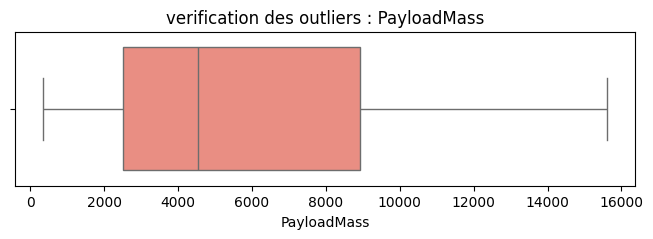

None


In [30]:
from sklearn.model_selection import train_test_split
from mon_outillage import compare_modele
from mon_outillage import pipeline_nettoyage_modele
from mon_outillage import cleaner_outlier
from mon_outillage import verifier_outlier

print(verifier_outlier(data_falcon9, 'PayloadMass'))


##-Ici on verifie les outliers pour ne pas fausse le modele avec les valeurs numeriques.Dans ce cas precis pour la masse utile, on voit que les 50% sont concentres dans la boite entre 2500 et 9000 kg et la mediane est au alentour de 4500kg .Les moustaches sont compris entre 0 et 16000kg .On en peut en conclure y a pas valeurs aberrantes d'apres la boite aux moustaches.

In [31]:
data_falcon9.shape

(90, 16)

In [32]:
#On separe X de la cible 
X = data_falcon9.drop(['class'], axis=1)

y = data_falcon9['class']


In [33]:
#on fait le split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#comparaison des differents modeles
comp = pipeline_nettoyage_modele(X_train)
table = compare_modele(X_train, X_test, y_train, y_test, comp)
print(table)

#Appliquer la fonction pipeline pour entrainer le modele
modele = pipeline_nettoyage_modele(X_train)

#on entraine
modele.fit(X_train, y_train)

#on predire
y_pred = modele.predict(X_test)



                modele  Score R2
0  logistic regression  1.000000
1        Random Forest  1.000000
2    Gradient Boosting  1.000000
3                  SVM  1.000000
5             AdaBoost  1.000000
4                  KNN  0.944444


----Evaluation du: KNN----
 Precision (Accuracy) : 94.44%
F1 score :96.30%
Precision :100.00%
recall : 92.86%
------------------------------


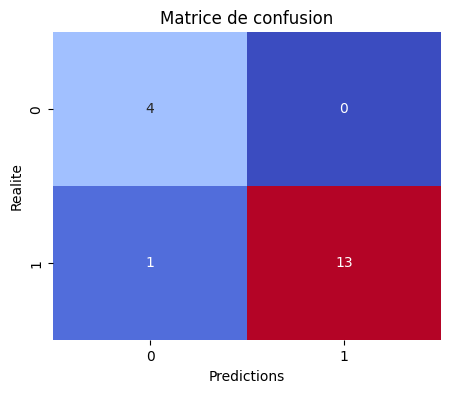

None


In [34]:
from mon_outillage import evaluer_classification

print(evaluer_classification(y_test, y_pred, "KNN"))

In [35]:
#verifier la stabilite par la cross validation
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from mon_outillage import valider_stabilite

#instancier l'object
mon_object = pipeline_nettoyage_modele(X_train)

 #Extraction manuelle depuis le pipeline de base
preprocessing = mon_object.named_steps['preprocessor']

#creation du pipeline poue le modele random forest
mike_pipe = make_pipeline(preprocessing, KNeighborsClassifier(n_neighbors=5))

score_vd = valider_stabilite(mike_pipe, X_train, y_train)

--- VALIDATION CROISÉE (5 Folds) ---
Moyenne des scores (accuracy) : 0.75%
Écart-type (instabilité)     : +/- 0.12%
le modele est stable et fiable


In [36]:
print(mike_pipe.named_steps.keys())

dict_keys(['columntransformer', 'kneighborsclassifier'])


In [37]:
from mon_outillage import optimiser_modele
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')


params_knn = {

   'kneighborsclassifier__n_neighbors': [3, 5, 7, 9],
   'kneighborsclassifier__weights': ['uniform', 'distance'],
   'kneighborsclassifier__algorithm': ['auto', 'ball_tree', 'kd_tree']
}


print(optimiser_modele(mike_pipe, params_knn, X_train,y_train))

Optimisation :
Fitting 5 folds for each of 24 candidates, totalling 120 fits
meilleur parametre : {'kneighborsclassifier__algorithm': 'auto', 'kneighborsclassifier__n_neighbors': 7, 'kneighborsclassifier__weights': 'uniform'}
meilleur score :77.62
Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['FlightNumber', 'PayloadMass', 'Reused', 'Block', 'Latitude',
       'Longitude', 'Flight'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
   

##-conclusion-
Avec la cross validation, la meilleur score est de 75% avec un ecart-type faible ce qui signifie que le modele est stable et fiable.
En faisant une optimisation avec les hyperparametres par le GridSearch avec le modele KNN, avec 5 folds, 24 candidats totale de 120 fits, on a reussi a avoir un score de 77%.
Avec ce resultat, le modele est capable de generer de nouvelles donnees sans trichers ni overfitting(aprendre par coeur)  


###-Verification finale pour tester les meilleurs parametres trouve

In [38]:
from mon_outillage import super_optimisateur

In [39]:

##Appliquer la fonction
print(super_optimisateur(mike_pipe, params_knn, X_train, y_train))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
------------------------------
MEILLEUR SCORE : 0.7762
MEILLEURS PARAMÈTRES : {'kneighborsclassifier__algorithm': 'auto', 'kneighborsclassifier__n_neighbors': 7, 'kneighborsclassifier__weights': 'uniform'}
------------------------------
Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['FlightNumber', 'PayloadMass', 'Reused', 'Block', 'Latitude',
       'Longitude', 'Flight'],
      dtype='object')),
                                                 ('cat',
                              

In [40]:
def generer_resume_rapport(modele_nom, score, params):
    print(f"--- RÉSUMÉ DU PROJET SPACEX ---")
    print(f"Modèle retenu : {modele_nom}")
    print(f"Précision validée : {score}%")
    print(f"Configuration optimale : {params}")
    print(f"Recommandation : Utiliser le site KSC LC 39A pour les tests de nouveaux boosters.")

# Utilisation avec tes résultats
generer_resume_rapport("KNN", 77.62, "{'n_neighbors': 7}")

--- RÉSUMÉ DU PROJET SPACEX ---
Modèle retenu : KNN
Précision validée : 77.62%
Configuration optimale : {'n_neighbors': 7}
Recommandation : Utiliser le site KSC LC 39A pour les tests de nouveaux boosters.


In [ ]:
data_falcon9

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,Reused,Leg,Serial,Block,GridFins,Latitude,Longitude,Outcome,LaunchSite,Flight,class
0,1,2010-06-04,Falcon 9,4535.0,LEO,0,False,B0003,1.0,False,28.561857,-80.577366,None None,CCSFS SLC 40,1,0
1,2,2012-05-22,Falcon 9,525.0,LEO,0,False,B0005,1.0,False,28.561857,-80.577366,None None,CCSFS SLC 40,1,0
2,3,2013-03-01,Falcon 9,677.0,ISS,0,False,B0007,1.0,False,28.561857,-80.577366,None None,CCSFS SLC 40,1,0
3,4,2013-09-29,Falcon 9,500.0,PO,0,False,B1003,1.0,False,34.632093,-120.610829,False Ocean,VAFB SLC 4E,1,0
4,5,2013-12-03,Falcon 9,3170.0,GTO,0,False,B1004,1.0,False,28.561857,-80.577366,None None,CCSFS SLC 40,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86,2020-09-03,Falcon 9,15600.0,VLEO,0,True,B1060,5.0,True,28.608058,-80.603956,True ASDS,KSC LC 39A,2,1
86,87,2020-10-06,Falcon 9,15600.0,VLEO,1,True,B1058,5.0,True,28.608058,-80.603956,True ASDS,KSC LC 39A,3,1
87,88,2020-10-18,Falcon 9,15600.0,VLEO,1,True,B1051,5.0,True,28.608058,-80.603956,True ASDS,KSC LC 39A,6,1
88,89,2020-10-24,Falcon 9,15600.0,VLEO,1,True,B1060,5.0,True,28.561857,-80.577366,True ASDS,CCSFS SLC 40,3,1


[2026-03-03 03:00:33,409] ERROR in app: Exception on /_dash-update-component [POST]
Traceback (most recent call last):
  File "c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 1473, in wsgi_app
    response = self.full_dispatch_request()
  File "c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 882, in full_dispatch_request
    rv = self.handle_user_exception(e)
  File "c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 880, in full_dispatch_request
    rv = self.dispatch_request()
  File "c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 865, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^
  File "c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\dash\_g